# 26. Alpha Signal Enhancement

## Objective
Improve the **true predictive power** of model signals (not execution/risk-management tricks) via stronger targets, richer features, and upgraded probability models.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple
import logging

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier

try:
    from lightgbm import LGBMClassifier
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 320)
pd.set_option('display.width', 240)

TRAIN_START = pd.Timestamp('2023-01-01')
TRAIN_END = pd.Timestamp('2024-12-31')
TEST_START = pd.Timestamp('2025-01-01')
TEST_END = pd.Timestamp('2025-12-31')

CLASS_HORIZON = 3  # change to 5 if needed
STRONG_MOVE_THRESHOLD = 0.02
RANDOM_STATE = 42
ANNUALIZATION_DAYS = 252

logger = logging.getLogger('alpha_signal_enhancement')
if not logger.handlers:
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))
    logger.addHandler(h)
logger.setLevel(logging.INFO)

if not HAS_LIGHTGBM:
    logger.info('LightGBM not available in this environment. Notebook will proceed with XGBoost models.')


In [2]:
def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'ml_pipeline').exists() and (c / 'CLAUDE.md').exists():
            return c
    raise FileNotFoundError('Unable to locate project root.')


ROOT = resolve_project_root()
DATA_PATH = ROOT / 'ml_pipeline' / 'Market_Data' / 'processed' / 'final_model_dataset_with_volatility.parquet'
OUT_PATH = ROOT / 'ml_pipeline' / 'Market_Data' / 'final' / 'improved_signal_dataset.parquet'

assert DATA_PATH.exists(), f'Missing dataset: {DATA_PATH}'

df = pd.read_parquet(DATA_PATH).copy()
df['Date'] = pd.to_datetime(df['Date'], errors='raise')
df['Ticker'] = df['Ticker'].astype(str)
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)
g_close = df.groupby('Ticker', sort=False)['Close']
g_ret = df.groupby('Ticker', sort=False)['Return']

# STEP 1: TARGET REDEFINITION
df['target_reg_t3'] = g_close.shift(-3) / df['Close'] - 1.0
df['target_reg_t5'] = g_close.shift(-5) / df['Close'] - 1.0
target_reg_col = f'target_reg_t{CLASS_HORIZON}'
assert target_reg_col in df.columns

df['target_strong_move'] = np.where(
    df[target_reg_col] > STRONG_MOVE_THRESHOLD,
    1,
    np.where(df[target_reg_col] < -STRONG_MOVE_THRESHOLD, 0, np.nan),
)

# STEP 2: FEATURE ENHANCEMENT
# 1) Momentum features
for w in [5, 10, 20]:
    df[f'mom_return_{w}d'] = g_close.pct_change(w)
df['rolling_mean_return_10d'] = g_ret.transform(lambda x: x.rolling(10, min_periods=5).mean())

# 2) Volatility regime features
df['realized_vol_20'] = g_ret.transform(lambda x: x.rolling(20, min_periods=10).std()) * np.sqrt(20)
df['atr_normalized'] = df['ATR'] / df['Close']

# 3) Cross-sectional features
df['cs_rank_return'] = df.groupby('Date')['Return'].rank(pct=True)
daily_ret_mean = df.groupby('Date')['Return'].transform('mean')
daily_ret_std = df.groupby('Date')['Return'].transform('std').replace(0, np.nan)
df['cs_zscore_return'] = ((df['Return'] - daily_ret_mean) / daily_ret_std).fillna(0.0)

df['cs_rank_mom_20d'] = df.groupby('Date')['mom_return_20d'].rank(pct=True)
daily_mom_mean = df.groupby('Date')['mom_return_20d'].transform('mean')
daily_mom_std = df.groupby('Date')['mom_return_20d'].transform('std').replace(0, np.nan)
df['cs_zscore_mom_20d'] = ((df['mom_return_20d'] - daily_mom_mean) / daily_mom_std).fillna(0.0)

# 4) Market-relative features
df['excess_return_vs_nifty'] = df['Return'] - df['NIFTY_RET']
df['mom_5d_minus_nifty'] = df['mom_return_5d'] - df.groupby('Ticker', sort=False)['NIFTY_RET'].transform(lambda x: x.rolling(5, min_periods=5).sum())

logger.info('Loaded rows: %s', f'{len(df):,}')
display(df[['Ticker', 'Date', target_reg_col, 'target_strong_move', 'mom_return_5d', 'realized_vol_20', 'cs_rank_return', 'excess_return_vs_nifty']].head(12))


[INFO] Loaded rows: 63,541


,Ticker,Date,target_reg_t3,target_strong_move,mom_return_5d,realized_vol_20,cs_rank_return,excess_return_vs_nifty
0,ABB,2023-04-18,-0.016959,NaN,NaN,NaN,0.258065,0.000199
1,ABB,2023-04-19,0.005108,NaN,NaN,NaN,0.537634,0.000564
2,ABB,2023-04-20,0.047671,1.0,NaN,NaN,0.322581,-0.002888
3,ABB,2023-04-21,0.078283,1.0,NaN,NaN,0.268817,-0.010059
4,ABB,2023-04-24,0.060359,1.0,NaN,NaN,0.838710,0.020350
5,ABB,2023-04-25,0.024535,1.0,0.040029,NaN,0.978495,0.030121
6,ABB,2023-04-26,0.012352,NaN,0.062198,NaN,0.956989,0.017742
7,ABB,2023-04-27,0.012311,NaN,0.071381,NaN,0.451613,0.000872
8,ABB,2023-04-28,0.066531,1.0,0.083928,NaN,0.204301,-0.003834
9,ABB,2023-05-02,0.080386,1.0,0.069855,0.065898,0.462366,0.007080


In [3]:
def max_drawdown(equity: pd.Series) -> float:
    running_max = equity.cummax()
    dd = equity / running_max - 1.0
    return float(dd.min()) if len(dd) else np.nan


def sharpe_ratio(daily_returns: pd.Series, annualization: int = ANNUALIZATION_DAYS) -> float:
    mu = float(daily_returns.mean())
    sigma = float(daily_returns.std(ddof=1))
    if sigma == 0.0 or np.isnan(sigma):
        return np.nan
    return (mu / sigma) * np.sqrt(annualization)


def evaluate_probs(name: str, y_true: np.ndarray, y_prob: np.ndarray) -> Dict[str, float]:
    y_pred = (y_prob >= 0.5).astype(int)
    pos_mask = y_true == 1
    neg_mask = y_true == 0
    return {
        'Model': name,
        'ROC_AUC': float(roc_auc_score(y_true, y_prob)),
        'PR_AUC': float(average_precision_score(y_true, y_prob)),
        'F1': float(f1_score(y_true, y_pred, zero_division=0)),
        'MeanAbsProbDist': float(np.mean(np.abs(y_prob - 0.5))),
        'ClassSeparation': float(y_prob[pos_mask].mean() - y_prob[neg_mask].mean()),
    }


base_features = [
    'Open', 'High', 'Low', 'Close', 'Volume', 'Return',
    'RSI', 'ROC', 'EMA_20', 'SMA_20', 'MACD', 'MACD_Signal',
    'ATR', 'Volatility_20', 'NIFTY_RET'
]
enhanced_only = [
    'mom_return_5d', 'mom_return_10d', 'mom_return_20d', 'rolling_mean_return_10d',
    'realized_vol_20', 'atr_normalized',
    'cs_rank_return', 'cs_zscore_return', 'cs_rank_mom_20d', 'cs_zscore_mom_20d',
    'excess_return_vs_nifty', 'mom_5d_minus_nifty'
]
base_features = [c for c in base_features if c in df.columns]
enhanced_features = base_features + [c for c in enhanced_only if c in df.columns]

model_df = df.dropna(subset=enhanced_features + ['target_strong_move', target_reg_col]).copy()
model_df['target_strong_move'] = model_df['target_strong_move'].astype(int)

train_mask = (model_df['Date'] >= TRAIN_START) & (model_df['Date'] <= TRAIN_END)
test_mask = (model_df['Date'] >= TEST_START) & (model_df['Date'] <= TEST_END)
assert train_mask.any() and test_mask.any(), 'Train/Test split is empty.'

X_train_base = model_df.loc[train_mask, base_features]
X_test_base = model_df.loc[test_mask, base_features]
X_train_enh = model_df.loc[train_mask, enhanced_features]
X_test_enh = model_df.loc[test_mask, enhanced_features]
y_train = model_df.loc[train_mask, 'target_strong_move'].to_numpy(dtype=int)
y_test = model_df.loc[test_mask, 'target_strong_move'].to_numpy(dtype=int)

neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = float(neg / max(pos, 1))
logger.info('Train class counts | neg=%d pos=%d scale_pos_weight=%.3f', neg, pos, scale_pos_weight)

# STEP 3: MODEL UPGRADE (XGB + optional LightGBM, with class weighting)
baseline_xgb = XGBClassifier(
    n_estimators=250,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
baseline_xgb.fit(X_train_base, y_train)
baseline_prob = baseline_xgb.predict_proba(X_test_base)[:, 1]

improved_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    min_child_weight=3,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=2.0,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
improved_xgb.fit(X_train_enh, y_train)
improved_xgb_prob = improved_xgb.predict_proba(X_test_enh)[:, 1]

candidates: Dict[str, np.ndarray] = {
    'Baseline-XGBoost': baseline_prob,
    'Enhanced-XGBoost': improved_xgb_prob,
}

if HAS_LIGHTGBM:
    improved_lgbm = LGBMClassifier(
        objective='binary',
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.85,
        colsample_bytree=0.85,
        class_weight={0: 1.0, 1: scale_pos_weight},
        random_state=RANDOM_STATE,
    )
    improved_lgbm.fit(X_train_enh, y_train)
    candidates['Enhanced-LightGBM'] = improved_lgbm.predict_proba(X_test_enh)[:, 1]

metrics_df = pd.DataFrame([evaluate_probs(name, y_test, probs) for name, probs in candidates.items()])
metrics_df = metrics_df.sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
display(metrics_df.round(4))

best_model_name = str(metrics_df.iloc[0]['Model'])
best_prob = candidates[best_model_name]
logger.info('Best model selected by ROC_AUC: %s', best_model_name)


[INFO] Train class counts | neg=6815 pos=9533 scale_pos_weight=0.715


[LightGBM] [Info] Number of positive: 9533, number of negative: 6815
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001250 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6856
[LightGBM] [Info] Number of data points in the train set: 16348, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,Model,ROC_AUC,PR_AUC,F1,MeanAbsProbDist,ClassSeparation
0,Enhanced-XGBoost,0.5329,0.5762,0.5238,0.1025,0.0197
1,Enhanced-LightGBM,0.5243,0.5601,0.5662,0.1735,0.0180
2,Baseline-XGBoost,0.5233,0.5668,0.6193,0.1298,0.0142


[INFO] Best model selected by ROC_AUC: Enhanced-XGBoost


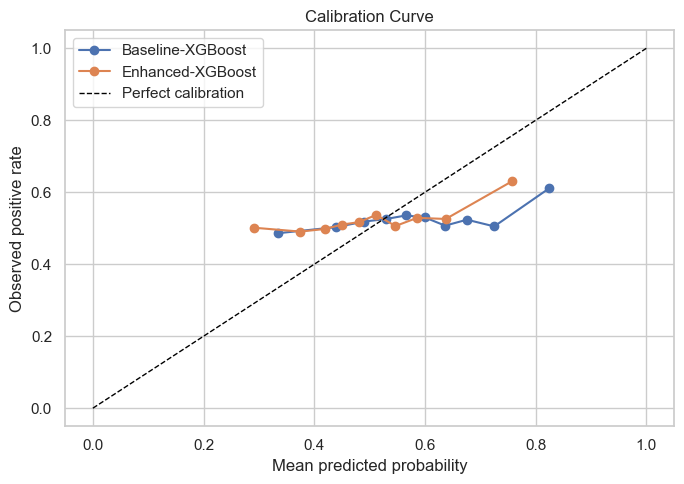

,Strategy,Total return,Sharpe ratio,Max drawdown,Win rate
0,Baseline decile long/short,0.1671,0.8773,-0.1882,0.5061
1,Improved decile long/short,0.1451,0.7501,-0.1751,0.5347


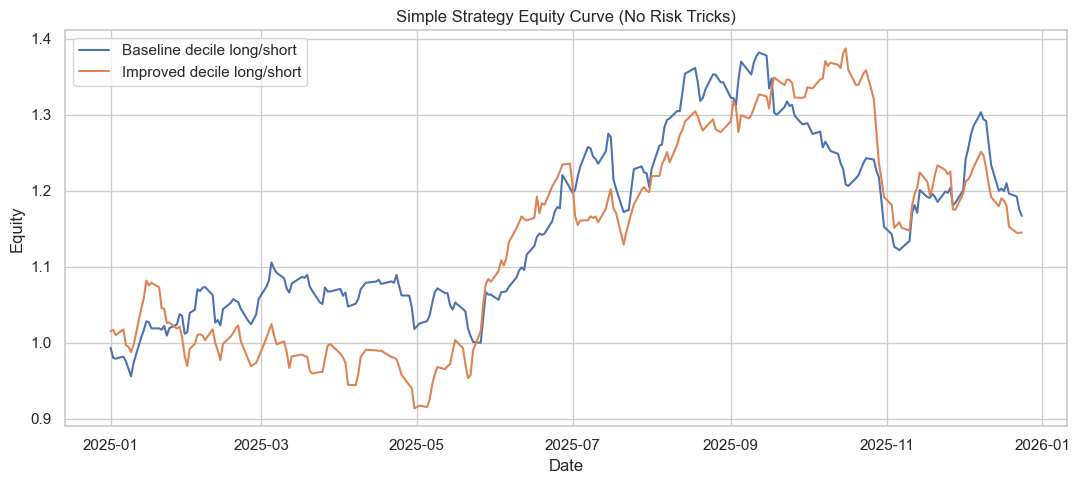

ROC improvement: +0.0096
F1 improvement: -0.0955
Signal strength improvement (mean |prob-0.5|): -0.0273
Class separation improvement: +0.0055
Saved improved signal dataset: c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\improved_signal_dataset.parquet
Notebook 26 completed: alpha signal enhancement executed.


In [4]:
# STEP 4: PROBABILITY QUALITY CHECK
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
for name, probs in [('Baseline-XGBoost', baseline_prob), (best_model_name, best_prob)]:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', linewidth=1.5, label=name)
ax.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1, label='Perfect calibration')
ax.set_title('Calibration Curve')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed positive rate')
ax.legend()
plt.tight_layout()
plt.show()

# STEP 5: SIGNAL STRENGTH TEST
baseline_metrics = metrics_df[metrics_df['Model'] == 'Baseline-XGBoost'].iloc[0]
best_metrics = metrics_df[metrics_df['Model'] == best_model_name].iloc[0]

signal_strength_improvement = float(best_metrics['MeanAbsProbDist'] - baseline_metrics['MeanAbsProbDist'])
class_separation_improvement = float(best_metrics['ClassSeparation'] - baseline_metrics['ClassSeparation'])

# STEP 6: SIMPLE STRATEGY TEST (Top 10% long / Bottom 10% short, no risk tricks)
test_out = model_df.loc[test_mask, ['Ticker', 'Date', 'target_strong_move', 'target_reg_t3', 'target_reg_t5']].copy()
test_out['prob_baseline'] = baseline_prob
test_out['prob_improved'] = best_prob
test_out['probability'] = test_out['prob_improved']
test_out['signal_strength'] = (test_out['probability'] - 0.5).abs()
test_out['future_return'] = test_out[target_reg_col]

def simple_long_short(df_in: pd.DataFrame, prob_col: str, ret_col: str) -> Tuple[pd.DataFrame, pd.Series, Dict[str, float]]:
    out_rows = []
    for dt, g in df_in.groupby('Date', sort=True):
        n = len(g)
        if n < 10:
            continue
        k = max(1, int(np.ceil(n * 0.10)))
        g = g.copy()
        g['rank_desc'] = g[prob_col].rank(method='first', ascending=False)
        g['rank_asc'] = g[prob_col].rank(method='first', ascending=True)
        g['side'] = 0
        g.loc[g['rank_desc'] <= k, 'side'] = 1
        g.loc[g['rank_asc'] <= k, 'side'] = -1
        picks = g[g['side'] != 0].copy()
        if len(picks) == 0:
            continue
        # 50% gross long + 50% gross short.
        picks['weight_abs'] = 0.5 / k
        picks['weight'] = picks['weight_abs'] * picks['side']
        picks['strategy_return'] = picks['weight'] * picks[ret_col]
        out_rows.append(picks)

    if not out_rows:
        empty = pd.DataFrame()
        return empty, pd.Series(dtype=float), {'Total return': np.nan, 'Sharpe ratio': np.nan, 'Max drawdown': np.nan, 'Win rate': np.nan}

    trades = pd.concat(out_rows, ignore_index=True)
    daily = trades.groupby('Date', as_index=True)['strategy_return'].sum().sort_index()
    equity = (1.0 + daily).cumprod()
    stats = {
        'Total return': float(equity.iloc[-1] - 1.0),
        'Sharpe ratio': sharpe_ratio(daily),
        'Max drawdown': max_drawdown(equity),
        'Win rate': float((daily > 0).mean()),
    }
    return trades, daily, stats

baseline_trades, baseline_daily, baseline_stats = simple_long_short(test_out, 'prob_baseline', 'future_return')
improved_trades, improved_daily, improved_stats = simple_long_short(test_out, 'prob_improved', 'future_return')

strategy_cmp = pd.DataFrame([
    {'Strategy': 'Baseline decile long/short', **baseline_stats},
    {'Strategy': 'Improved decile long/short', **improved_stats},
])
display(strategy_cmp.round(4))

plt.figure(figsize=(11, 5))
if len(baseline_daily) > 0:
    plt.plot((1.0 + baseline_daily).cumprod(), label='Baseline decile long/short')
if len(improved_daily) > 0:
    plt.plot((1.0 + improved_daily).cumprod(), label='Improved decile long/short')
plt.title('Simple Strategy Equity Curve (No Risk Tricks)')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.legend()
plt.tight_layout()
plt.show()

# STEP 7: OUTPUT
roc_improvement = float(best_metrics['ROC_AUC'] - baseline_metrics['ROC_AUC'])
f1_improvement = float(best_metrics['F1'] - baseline_metrics['F1'])

print(f'ROC improvement: {roc_improvement:+.4f}')
print(f'F1 improvement: {f1_improvement:+.4f}')
print(f'Signal strength improvement (mean |prob-0.5|): {signal_strength_improvement:+.4f}')
print(f'Class separation improvement: {class_separation_improvement:+.4f}')

test_out['pred_label_improved'] = (test_out['prob_improved'] >= 0.5).astype(int)
test_out['signal_strength_improved'] = (test_out['prob_improved'] - 0.5).abs()

if len(improved_trades) > 0:
    improved_tag = improved_trades[['Ticker', 'Date', 'side', 'weight', 'strategy_return']].rename(
        columns={'side': 'simple_strategy_side', 'weight': 'simple_strategy_weight', 'strategy_return': 'simple_strategy_return'}
    )
    save_df = test_out.merge(improved_tag, on=['Ticker', 'Date'], how='left')
else:
    save_df = test_out.copy()
    save_df['simple_strategy_side'] = np.nan
    save_df['simple_strategy_weight'] = np.nan
    save_df['simple_strategy_return'] = np.nan

save_df['model_selected'] = best_model_name
save_df['class_horizon'] = CLASS_HORIZON
save_df['strong_move_threshold'] = STRONG_MOVE_THRESHOLD

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
save_df.to_parquet(OUT_PATH, index=False)

print(f'Saved improved signal dataset: {OUT_PATH}')
print('Notebook 26 completed: alpha signal enhancement executed.')
